# Phase 0 — Data Acquisition and Cleaning

**Goal:** produce a clean $T \times N$ matrix $R$ of daily log returns for NSE equities,
plus a documented record of every cleaning decision. This feeds **Section 4 (Data)** of the paper.

**Universe:** Nifty Total Market constituents (750 names = Nifty 500 + Nifty Microcap 250),
the broadest NSE index with an official constituent list. Rationale: with a small universe
(e.g. Nifty 50), $N \approx 50$ against $T \approx 1240$ gives $q = N/T \approx 0.04$ — a
narrow Marchenko–Pastur band and only ~40 bulk eigenvalues, far too few for the GOE spacing
statistics in Phase 3 to have power. The Total Market universe retains $N \gtrsim 550$ names
after cleaning, giving $q \approx 0.45$ over the full sample — a wide, well-populated MP
band, hundreds of bulk eigenvalues for spacing statistics, and $N$ *comparable to or larger
than* the estimation window in the rolling backtest (Phase 7), which is exactly the regime
where covariance cleaning is not cosmetic but necessary for the raw estimator to be usable
at all. The microcap tail also stress-tests the cleaning pipeline (staleness, liquidity),
which the filters below handle explicitly.

**Data source:** Yahoo Finance via `yfinance` with `.NS` suffixes, `auto_adjust=True`
(splits and dividends folded into close prices). `nsepy` is unmaintained and `jugaad-data`
breaks with NSE's anti-scraping changes; Yahoo is stable and gives adjusted closes directly.

**Known limitation (state this in the paper):** the universe is the *current* constituent
list, so stocks that left the index during the sample are excluded — survivorship bias.
This is standard in the RMT-finance literature (Laloux et al. 1999; Plerou et al. 2002 use
fixed universes) and, importantly, it affects all three covariance estimators compared in
Phase 7 *identically*, so relative conclusions are unaffected.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json

import numpy as np
import pandas as pd
import requests
import yfinance as yf
import matplotlib.pyplot as plt

# ----------------------------- configuration (Appendix: hyperparameters)
INDEX            = "niftytotalmarket"  # "nifty50" | "nifty200" | "nifty500" | "niftytotalmarket"
START            = "2021-07-01"   # sample start (inclusive)
END              = "2026-06-30"   # sample end   (inclusive)
MIN_DAY_COVERAGE = 0.90           # a date is a trading day if >=90% of tickers have a price
MAX_MISSING_FRAC = 0.005          # drop tickers missing >0.5% of trading days
MAX_FFILL_DAYS   = 5              # forward-fill gaps of at most 5 consecutive sessions
MAX_ZERO_FRAC    = 0.15           # drop tickers with >15% exact-zero returns (stale/illiquid)

# Corporate-action artifacts in the Yahoo source data, found by screening all
# |r| > 20% events and every January-1 move, then manually verifying each flag
# against news/exchange records (procedure documented in section 4 below).
# These series are unrepairable from prices alone and are excluded.
MANUAL_EXCLUDE = {
    # -- bonus/split adjustments stamped on the wrong date by Yahoo (spurious cliff)
    "MOTILALOFS.NS": "3:1 bonus (true ex-date 2024-06-10) misdated to 2024-01-01; spurious -75%",
    "TRENT.NS":      "1:2 bonus (true ex-date 2026-06-04) misdated to 2026-01-01; spurious -33%",
    "CONCOR.NS":     "1:4 bonus (true record date 2025-07-04) misdated to 2025-01-01; spurious -21%",
    "GPIL.NS":       "1:5 split (true record date 2024-10-04) misdated to 2024-01-01; spurious -79%",
    "CGCL.NS":       "1:2 split + 1:1 bonus, x4 factor (true record date 2024-03-05) misdated to 2024-01-01; spurious -75%",
    "PARAS.NS":      "1:1 split Rs10->Rs5 (true record date 2025-07-04) misdated to 2025-01-01; spurious -50%",
    "JSLL.NS":       "10:2 split (true ex-date 2025-06-12) misdated to 2025-06-03; spurious -78%",
    # -- demergers left unadjusted: mechanical ex-date price drop is not a shareholder return
    "VEDL.NS":       "5-way demerger ex 2026-04-30; -63% mechanical adjustment",
    "TMPV.NS":       "Tata Motors CV demerger record 2025-10-14; Rs 660.75 -> 400 mechanical adjustment",
    "ABFRL.NS":      "lifestyle-brands demerger record 2025-05-22; Rs 269 -> 98 mechanical adjustment",
    "SKFINDIA.NS":   "industrial-business demerger record 2025-10-15; Rs 5008 -> 2400 mechanical adjustment",
    "STAR.NS":       "OneSource CDMO demerger record 2024-12-06; -54% mechanical adjustment",
    "QUESS.NS":      "three-way demerger (Digitide+Bluspring) record 2025-04-15; -51% mechanical adjustment",
    "STLTECH.NS":    "STL Networks demerger record 2025-04-24; -25% mechanical adjustment",
    "SCI.NS":        "SCILAL land-assets demerger record 2023-03-31; -22% mechanical adjustment",
}

DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)

# Okabe-Ito colorblind-safe palette, fixed order (used across all phases)
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10, "axes.titlesize": 11,
})

print(f"config: {INDEX}, {START} .. {END}")

config: niftytotalmarket, 2021-07-01 .. 2026-06-30


## 1. Universe

Pull the official constituent list from NSE's archives and snapshot it to disk
(`data/universe_snapshot.csv`) so the exact universe is frozen for reproducibility —
the live list changes at semi-annual index reviews. If NSE is unreachable, the cell
falls back to the saved snapshot.

In [2]:
SNAPSHOT = DATA_DIR / "universe_snapshot.csv"

def fetch_constituents(index_name: str) -> pd.DataFrame:
    from io import StringIO
    last_err = None
    for slug in (f"ind_{index_name}list.csv", f"ind_{index_name}_list.csv"):
        try:
            url = f"https://archives.nseindia.com/content/indices/{slug}"
            r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
            r.raise_for_status()
            return pd.read_csv(StringIO(r.text))
        except Exception as e:
            last_err = e
    raise last_err

try:
    universe = fetch_constituents(INDEX)
    universe.to_csv(SNAPSHOT, index=False)
    print(f"fetched live constituent list ({len(universe)} names) -> {SNAPSHOT}")
except Exception as e:
    if SNAPSHOT.exists():
        universe = pd.read_csv(SNAPSHOT)
        print(f"NSE unreachable ({e!r}); using saved snapshot ({len(universe)} names)")
    else:
        raise RuntimeError("No constituent list available") from e

universe = universe[~universe["Symbol"].str.startswith("DUMMY")]  # NSE placeholder rows
tickers = sorted(universe["Symbol"].str.strip() + ".NS")
print(f"{len(tickers)} tickers, e.g. {tickers[:5]}")
universe.head()

fetched live constituent list (751 names) -> data/universe_snapshot.csv
750 tickers, e.g. ['360ONE.NS', '3MINDIA.NS', 'AADHARHFC.NS', 'AARTIDRUGS.NS', 'AARTIIND.NS']


,Company Name,Industry,Symbol,Series,ISIN Code
0,360 ONE WAM Ltd.,Financial Services,360ONE,EQ,INE466L01038
1,3M India Ltd.,Diversified,3MINDIA,EQ,INE470A01017
2,ABB India Ltd.,Capital Goods,ABB,EQ,INE117A01022
3,ACC Ltd.,Construction Materials,ACC,EQ,INE012A01025
4,ACME Solar Holdings Ltd.,Power,ACMESOLAR,EQ,INE622W01025


## 2. Download adjusted close prices

`auto_adjust=True` returns split- and dividend-adjusted closes, so no manual corporate-action
handling is needed. `end` is exclusive in `yfinance`, hence the `+1 day`. Tickers that fail
entirely (renamed symbols, recent listings with no Yahoo history) are retried once
individually, then recorded as dropped.

In [3]:
import time

end_excl = (pd.Timestamp(END) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

frames, CHUNK = [], 150
for i in range(0, len(tickers), CHUNK):
    raw = yf.download(tickers[i:i+CHUNK], start=START, end=end_excl,
                      auto_adjust=True, progress=False, threads=True)
    frames.append(raw["Close"])
    time.sleep(2)  # be polite to the API across ~5 chunks
prices = pd.concat(frames, axis=1).sort_index()
prices = prices.loc[:, ~prices.columns.duplicated()]
prices.index = pd.to_datetime(prices.index).tz_localize(None)

failed = [t for t in tickers if t not in prices.columns or prices[t].isna().all()]
if failed:  # one retry pass, sequential
    for t in failed:
        try:
            s = yf.download(t, start=START, end=end_excl, auto_adjust=True,
                            progress=False)["Close"]
            if isinstance(s, pd.DataFrame):
                s = s.iloc[:, 0]
            if s.notna().sum() > 0:
                prices[t] = s
        except Exception:
            pass
    failed = [t for t in tickers if t not in prices.columns or prices[t].isna().all()]

dropped = {t: "download failed / no Yahoo history" for t in failed}
prices = prices.drop(columns=failed, errors="ignore").sort_index()
print(f"downloaded: {prices.shape[1]} tickers x {prices.shape[0]} dates")
print(f"failed downloads ({len(failed)}): {failed}")

downloaded: 750 tickers x 1237 dates
failed downloads (0): []


## 3. Cleaning

Applied in order, each rule recorded with the tickers it removes:

1. **Full-history filter** — a ticker's first observation must fall within the first 3
   sessions of the sample. Removes mid-window IPOs and listings (e.g. LIC, May 2022; the
   2021–24 IPO wave contributes ~150 exclusions in this universe) rather than imputing years
   of nonexistent prices. *Order matters:* this must run before the trading-day filter, else
   pre-listing NaNs masquerade as poor day coverage and delete valid early-sample dates.
2. **Trading-day filter** — keep dates where ≥ 90% of *full-history* tickers have a price.
   Removes NSE holidays that leak in and stray half-sessions, without letting one stock's
   gap delete a day.
3. **Coverage filter** — after (2), drop tickers still missing > 0.5% of sessions.
4. **Gap fill** — forward-fill remaining gaps of ≤ 5 consecutive sessions (trading halts,
   circuit breakers). A held price produces a zero return, which is the economically correct
   value for a halt. Anything still missing ⇒ drop.
5. **Corporate-action verification** — every single-day move with $|r| > 15\%$ was screened
   for artifact signatures (price ratio near a round fraction such as 1/4 or 2/3; occurrence
   on the thin January-1 session, where Yahoo Finance turns out to stamp misdated Indian
   bonus adjustments) and each flagged event was manually verified against news and exchange
   records. Five tickers carry unrepairable artifacts and are excluded (see §4 below).
   Crucially, verification also *cleared* several genuine crashes that naive clipping would
   have destroyed: the Adani short-seller episode (Feb 2023), the IndusInd Bank disclosure
   (Mar 2025), the election-result day (4 Jun 2024), and the tobacco-tax shock that hit ITC
   (−10%) and Godfrey Phillips (−19%) on 1 Jan 2026.
6. **Staleness filter** — applied after returns are computed: drop tickers whose returns are
   exactly zero on > 15% of days. Stale quotes bias pairwise correlations toward zero and
   contaminate the spectrum's bulk — the very object under study.

In [4]:
P = prices.copy()

# (1) full-history filter (must precede the day filter: pre-listing NaNs would
#     otherwise read as poor day coverage and delete valid early-sample dates)
cutoff = P.index[2]
late = [t for t in P.columns if P[t].first_valid_index() is None or P[t].first_valid_index() > cutoff]
for t in late:
    fv = P[t].first_valid_index()
    dropped[t] = f"incomplete history (first obs {fv.date() if fv else 'never'})"
P = P.drop(columns=late)
print(f"(1) dropped {len(late)} mid-window listings: {sorted(late)}")

# (2) trading-day filter, coverage measured among full-history tickers
day_cov = P.notna().mean(axis=1)
P = P.loc[day_cov >= MIN_DAY_COVERAGE]
print(f"(2) trading days retained: {len(P)}  (removed {int((day_cov < MIN_DAY_COVERAGE).sum())} dates)")

# (3) coverage filter
miss = P.isna().mean()
sparse = miss[miss > MAX_MISSING_FRAC].index.tolist()
for t in sparse:
    dropped[t] = f"missing {miss[t]:.1%} of sessions"
P = P.drop(columns=sparse)
print(f"(3) dropped {len(sparse)} sparse tickers: {sorted(sparse)}")

# (4) bounded forward fill
n_filled = int(P.isna().sum().sum())
P = P.ffill(limit=MAX_FFILL_DAYS)
still = P.columns[P.isna().any()].tolist()
for t in still:
    dropped[t] = "gaps longer than ffill limit"
P = P.drop(columns=still)
print(f"(4) forward-filled {n_filled} cells; dropped {len(still)} tickers with long gaps: {sorted(still)}")

# (5) verified corporate-action artifacts (see markdown documentation below)
bad = [t for t in MANUAL_EXCLUDE if t in P.columns]
for t in bad:
    dropped[t] = MANUAL_EXCLUDE[t]
P = P.drop(columns=bad)
print(f"(5) dropped {len(bad)} tickers with verified data artifacts: {sorted(bad)}")

prices_clean = P
print(f"\nafter price-level cleaning: {P.shape[1]} tickers x {P.shape[0]} days")

(1) dropped 187 mid-window listings: ['AADHARHFC.NS', 'AARTIPHARM.NS', 'ABDL.NS', 'ABLBL.NS', 'ABSLAMC.NS', 'ACI.NS', 'ACMESOLAR.NS', 'ACUTAAS.NS', 'AEGISVOPAK.NS', 'AEQUS.NS', 'AETHER.NS', 'AFCONS.NS', 'AGARWALEYE.NS', 'AIIL.NS', 'AKUMS.NS', 'ALIVUS.NS', 'ANANDRATHI.NS', 'ANTHEM.NS', 'APTUS.NS', 'ASKAUTOLTD.NS', 'ATHERENERG.NS', 'ATLANTAELE.NS', 'AVALON.NS', 'AVL.NS', 'AWFIS.NS', 'AWL.NS', 'AZAD.NS', 'BAJAJHFL.NS', 'BALUFORGE.NS', 'BELRISE.NS', 'BHARTIHEXA.NS', 'BIKAJI.NS', 'BLACKBUCK.NS', 'BLUEJET.NS', 'BLUESTONE.NS', 'CAMPUS.NS', 'CANHLIFE.NS', 'CAPILLARY.NS', 'CARTRADE.NS', 'CELLO.NS', 'CHOICEIN.NS', 'CLEAN.NS', 'CMSINFO.NS', 'CONCORDBIO.NS', 'CORONA.NS', 'CPPLUS.NS', 'CRAMC.NS', 'CRIZAC.NS', 'DATAPATTNS.NS', 'DELHIVERY.NS', 'DEVYANI.NS', 'DOMS.NS', 'EIEL.NS', 'ELLEN.NS', 'EMCURE.NS', 'EMIL.NS', 'EMMVEE.NS', 'ENRIN.NS', 'ENTERO.NS', 'ETERNAL.NS', 'ETHOSLTD.NS', 'EUREKAFORB.NS', 'FEDFINA.NS', 'FIRSTCRY.NS', 'FIVESTAR.NS', 'GMRP&UI.NS', 'GODIGIT.NS', 'GROWW.NS', 'GRWRHITECH.NS', 'HDB

## 4. Log returns and staleness/outlier checks

$$r_{t,i} = \ln\!\left(\frac{P_{t,i}}{P_{t-1,i}}\right)$$

Extreme returns are **inspected and verified, never clipped**. Naive winsorization would have
destroyed genuine market events while keeping vendor bugs. The verification procedure behind
`MANUAL_EXCLUDE` (documented here for the paper's Data section):

1. List every observation with $|r| > 20\%$ and every move on a January-1 session (thin
   trading; the signature date on which Yahoo stamps misdated Indian corporate-action
   adjustments).
2. Flag events whose price ratio $e^{r}$ falls within ~1% of a round fraction
   (1/5, 1/4, 1/2, 2/3, …) — the fingerprint of a misdated bonus/split — or that coincide
   with a demerger record date. Note that $e^{r} = 0.800$ exactly is usually a **20%
   lower-circuit lock**, i.e. a *real* limit-down day, so ratio alone is insufficient:
   every flag was checked against contemporaneous news and exchange records.
3. **Excluded — misdated bonus/split adjustments** (spurious cliff on a date when no such
   move occurred; true ex-date verified): MOTILALOFS (−75%, cliff 1 Jan 2024, true ex-date
   10 Jun 2024), TRENT (−33%, 1 Jan 2026, true 4 Jun 2026), CONCOR (−21%, 1 Jan 2025, true
   4 Jul 2025), GPIL (−79%, 1 Jan 2024, true 4 Oct 2024), CGCL (−75%, 1 Jan 2024, true
   5 Mar 2024), PARAS (−50%, 1 Jan 2025, true 4 Jul 2025), JSLL (−78%, 3 Jun 2025, true
   12 Jun 2025).
4. **Excluded — unadjusted demergers** (ex-date price drop is mechanical, shareholders
   received shares of the spun-off entity; no valid adjustment computable from prices
   alone): VEDL (30 Apr 2026, 5-way split), TMPV (14 Oct 2025, CV business), ABFRL
   (22 May 2025, lifestyle brands), SKFINDIA (15 Oct 2025, industrial), STAR (6 Dec 2024,
   OneSource), QUESS (15 Apr 2025, three-way), STLTECH (24 Apr 2025, STL Networks), SCI
   (31 Mar 2023, SCILAL).
5. **Verified real and kept**: ADANIENT −33%/−31% (Hindenburg, Feb 2023); INDUSINDBK −32%
   (derivatives disclosure, Mar 2025); ZEEL −34% (Sony merger collapse, 23 Jan 2024); IEX
   −30% (CERC market-coupling order, 24 Jul 2025); the 4 Jun 2024 election-result crash
   (RECLTD, PFC, BHEL, SAIL, …); the 1 Jan 2026 tobacco-tax shock (ITC −10%, GODFRYPHLP
   −19% — a genuine Jan-1 crash, correctly retained despite the suspicious date); RBLBANK
   −23% (CEO succession, Jun 2022); and dozens of exact −20% lower-circuit locks among
   mid/small caps.
6. Demergers that Yahoo *did* adjust correctly (SIEMENS/Siemens Energy Apr 2025, ITC/ITC
   Hotels Jan 2025, RELIANCE/Jio Financial Jul 2023) show no cliff and are retained —
   confirming the screen targets vendor errors, not demergers per se. For each excluded
   misdated adjustment, the window around the *true* ex-date was checked to confirm the
   series contains exactly one (misplaced) cliff, not two.

In [5]:
R = np.log(prices_clean).diff().iloc[1:]

# (6) staleness filter
zero_frac = (R == 0.0).mean()
stale = zero_frac[zero_frac > MAX_ZERO_FRAC].index.tolist()
for t in stale:
    dropped[t] = f"stale: {zero_frac[t]:.1%} zero-return days"
R = R.drop(columns=stale)
prices_clean = prices_clean.drop(columns=stale)
print(f"(6) dropped {len(stale)} stale/illiquid tickers: {sorted(stale)}")
print(f"median zero-return fraction across retained tickers: {zero_frac.drop(stale).median():.2%}")

# extreme-move inspection
flat = R.stack()
extremes = flat.reindex(flat.abs().sort_values(ascending=False).index).head(10)
print(f"\n|r| > 20% events: {(flat.abs() > 0.20).sum()} of {len(flat):,} observations")
print("\n10 largest single-day log returns (inspect against real events):")
print(extremes.rename("log_return").to_frame().rename_axis(["date", "ticker"]).round(4))

(6) dropped 1 stale/illiquid tickers: ['DIACABS.NS']
median zero-return fraction across retained tickers: 0.65%

|r| > 20% events: 99 of 677,328 observations

10 largest single-day log returns (inspect against real events):
                          log_return
date       ticker                   
2024-01-23 ZEEL.NS           -0.4101
2025-07-24 IEX.NS            -0.3506
2021-09-14 ZEEL.NS            0.3363
2023-02-01 ADANIENT.NS       -0.3312
2025-03-11 INDUSINDBK.NS     -0.3169
2023-02-02 ADANIENT.NS       -0.3106
2024-06-04 RECLTD.NS         -0.2903
2021-09-22 ZEEL.NS            0.2755
2025-01-24 CYIENT.NS         -0.2663
2024-06-04 PFC.NS            -0.2624


## 5. Final dataset and diagnostics

The headline numbers of the Data section: $T$, $N$, and the aspect ratio $q = N/T$ that
drives everything downstream. Figures: (a) data availability through time before cleaning,
(b) adjusted prices for five large caps (sanity: no un-adjusted split cliffs),
(c) pooled daily return distribution on a log scale against a Gaussian fit — the fat tails
motivate the robust variance handling discussed in Phase 2.

T = 1236 trading days   N = 548 stocks   q = N/T = 0.4434
sample: 2021-07-02 .. 2026-06-30
universe 750 -> retained 548  (dropped 202)


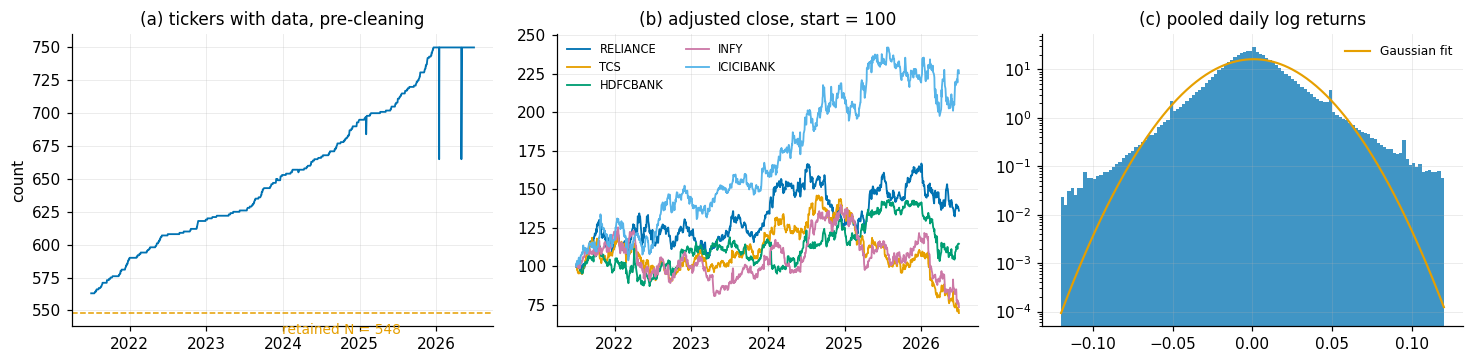

In [6]:
T, N = R.shape
q = N / T
print(f"T = {T} trading days   N = {N} stocks   q = N/T = {q:.4f}")
print(f"sample: {R.index[0].date()} .. {R.index[-1].date()}")
print(f"universe {len(tickers)} -> retained {N}  (dropped {len(dropped)})")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))

# (a) availability
avail = prices.notna().sum(axis=1)
axes[0].plot(avail.index, avail.values, color=PALETTE[0], lw=1.2)
axes[0].axhline(N, color=PALETTE[1], lw=1, ls="--")
axes[0].annotate(f"retained N = {N}", xy=(avail.index[len(avail)//2], N),
                 xytext=(0, -14), textcoords="offset points", color=PALETTE[1], fontsize=9)
axes[0].set_title("(a) tickers with data, pre-cleaning")
axes[0].set_ylabel("count")

# (b) large-cap adjusted prices, indexed to 100
show = [t for t in ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]
        if t in prices_clean.columns][:5]
idx100 = 100 * prices_clean[show] / prices_clean[show].iloc[0]
for i, t in enumerate(show):
    axes[1].plot(idx100.index, idx100[t], color=PALETTE[i], lw=1.2, label=t.replace(".NS", ""))
axes[1].legend(fontsize=7.5, frameon=False, ncol=2)
axes[1].set_title("(b) adjusted close, start = 100")

# (c) pooled return distribution vs Gaussian
r_all = R.values.ravel()
mu, sd = r_all.mean(), r_all.std()
bins = np.linspace(-0.12, 0.12, 121)
axes[2].hist(r_all, bins=bins, density=True, color=PALETTE[0], alpha=0.75)
xg = np.linspace(-0.12, 0.12, 400)
axes[2].plot(xg, np.exp(-(xg - mu)**2 / (2 * sd**2)) / (sd * np.sqrt(2 * np.pi)),
             color=PALETTE[1], lw=1.4, label="Gaussian fit")
axes[2].set_yscale("log")
axes[2].set_title("(c) pooled daily log returns")
axes[2].legend(fontsize=8, frameon=False)

fig.tight_layout()
fig.savefig(DATA_DIR / "fig_phase0_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Persist outputs

Everything later phases need, plus the audit trail for the paper's appendix:

- `data/returns_daily.parquet` — the $T \times N$ log-return matrix $R$ (CSV copy alongside)
- `data/prices_adjclose.parquet` — cleaned adjusted closes
- `data/dropped_tickers.csv` — every excluded ticker with the reason
- `data/dataset_summary.json` — all headline numbers and cleaning parameters

In [7]:
R.to_parquet(DATA_DIR / "returns_daily.parquet")
R.to_csv(DATA_DIR / "returns_daily.csv")
prices_clean.to_parquet(DATA_DIR / "prices_adjclose.parquet")

pd.Series(dropped, name="reason").rename_axis("ticker").sort_index() \
    .to_csv(DATA_DIR / "dropped_tickers.csv")

summary = {
    "index": INDEX, "start": str(R.index[0].date()), "end": str(R.index[-1].date()),
    "T": int(T), "N": int(N), "q": round(q, 6),
    "universe_size": len(tickers), "n_dropped": len(dropped),
    "params": {"MIN_DAY_COVERAGE": MIN_DAY_COVERAGE, "MAX_MISSING_FRAC": MAX_MISSING_FRAC,
               "MAX_FFILL_DAYS": MAX_FFILL_DAYS, "MAX_ZERO_FRAC": MAX_ZERO_FRAC},
    "source": f"Yahoo Finance via yfinance {yf.__version__}, auto_adjust=True",
    "retrieved_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
(DATA_DIR / "dataset_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

{
  "index": "niftytotalmarket",
  "start": "2021-07-02",
  "end": "2026-06-30",
  "T": 1236,
  "N": 548,
  "q": 0.443366,
  "universe_size": 750,
  "n_dropped": 202,
  "params": {
    "MIN_DAY_COVERAGE": 0.9,
    "MAX_MISSING_FRAC": 0.005,
    "MAX_FFILL_DAYS": 5,
    "MAX_ZERO_FRAC": 0.15
  },
  "source": "Yahoo Finance via yfinance 1.5.1, auto_adjust=True",
  "retrieved_utc": "2026-07-22T14:28:53+00:00"
}


## 7. Draft text for Section 4 (Data)

Generated with the actual numbers substituted — edit the prose, keep the figures honest.

In [8]:
n_by_reason = pd.Series(dropped).str.split(":").str[0].str.split("(").str[0].str.strip().value_counts()
reasons = "; ".join(f"{v} {k}" for k, v in n_by_reason.items())

draft = f'''Our universe is the constituent list of the Nifty Total Market index as of the
retrieval date ({summary["retrieved_utc"][:10]}), which unites the Nifty 500 with the
Nifty Microcap 250 and spans large-, mid-, small- and micro-capitalization NSE equities.
We obtain daily split- and dividend-adjusted closing prices from Yahoo Finance for the
period {summary["start"]} to {summary["end"]}. Of the {summary["universe_size"]}
constituents, {summary["n_dropped"]} are excluded ({reasons}), leaving N = {N} stocks
observed over T = {T} trading days and a log-return matrix R of aspect ratio
q = N/T = {q:.3f}. The dominant exclusion is the full-history requirement: the 2021-24
IPO wave means roughly 150 current constituents listed after our sample start, and we
drop them rather than impute nonexistent history. Gaps of at most {MAX_FFILL_DAYS}
consecutive sessions (trading halts) are forward-filled, producing zero returns; stocks
with zero returns on more than {MAX_ZERO_FRAC:.0%} of days are excluded, since stale
quotes bias sample correlations toward zero and distort the bulk of the spectrum that
our analysis targets. All single-day moves exceeding 20% in absolute value, and all
moves on January-1 sessions, were screened against corporate-action records: fifteen
constituents carry unrepairable vendor-data artifacts (seven bonus/split adjustments
stamped on the wrong date, eight demerger price adjustments that are not shareholder
returns) and are excluded, while verified genuine events -- including the February 2023
Adani episode, the June 2024 election-day crash, the January 2026 tobacco-tax shock,
and dozens of 20% lower-circuit locks -- are retained unmodified; we deliberately apply
no winsorization or clipping. Because the universe is the current constituent list, the sample carries
survivorship bias; as all covariance estimators compared in Section 5 are estimated on
the identical universe, this does not affect their relative evaluation.'''

print(draft)
(DATA_DIR / "section4_data_draft.md").write_text(draft)

Our universe is the constituent list of the Nifty Total Market index as of the
retrieval date (2026-07-22), which unites the Nifty 500 with the
Nifty Microcap 250 and spans large-, mid-, small- and micro-capitalization NSE equities.
We obtain daily split- and dividend-adjusted closing prices from Yahoo Finance for the
period 2021-07-02 to 2026-06-30. Of the 750
constituents, 202 are excluded (187 incomplete history; 4 1; 1 missing 3.3% of sessions; 1 3; 1 5-way demerger ex 2026-04-30; -63% mechanical adjustment; 1 Tata Motors CV demerger record 2025-10-14; Rs 660.75 -> 400 mechanical adjustment; 1 lifestyle-brands demerger record 2025-05-22; Rs 269 -> 98 mechanical adjustment; 1 industrial-business demerger record 2025-10-15; Rs 5008 -> 2400 mechanical adjustment; 1 OneSource CDMO demerger record 2024-12-06; -54% mechanical adjustment; 1 three-way demerger; 1 STL Networks demerger record 2025-04-24; -25% mechanical adjustment; 1 SCILAL land-assets demerger record 2023-03-31; -22% mecha

2472